In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 134.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="NbbkRMsNQxoHqz6BFwN0")
project = rf.workspace("gtsrbanno").project("traffic-sign-detection-gtsrb")
version = project.version(15)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-sign-detection-gtsrb-15 in yolov8:: 100%|██████████| 8409/8409 [00:01<00:00, 4498.52it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)


Using device: cuda


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # Medium variant for better accuracy

In [ ]:
# ====================================================
# 🏋️ Train YOLOv8m on GTSDB Dataset (Fine-Tuned)
# ====================================================

results = model.train(
    data=f"{dataset.location}/data.yaml",  # path to your dataset config
    epochs=100,                            # longer training for better convergence
    imgsz=640,
    batch=16,
    lr0=0.0005,                            # lower learning rate for smoother updates
    optimizer="Adam",
    mosaic=0.5,                            # reduced for validation stability
    mixup=0.1,                             # reduced to preserve label clarity
    cache=True,
    pretrained=True,
    name="traffic_sign_yolov8m_finetuned",# new run name
    exist_ok=True,
    patience=10                            # early stopping if val loss plateaus
)

print("\n✅ Training completed!")
print("📂 Model saved to: runs/detect/traffic_sign_yolov8m_finetuned/weights/best.pt")

Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/traffic-sign-detection-gtsrb-15/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=traffic_sign_yolov8m_finetuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, p

testing

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure inline plotting in Colab
%matplotlib inline

# Path to YOLOv8 results
results_dir = "runs/detect/traffic_sign_yolov8n_80ep"
csv_path = f"{results_dir}/results.csv"

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    # Apply rolling average for smoothing
    window = 5
    df['precision_smooth'] = df['metrics/precision(B)'].rolling(window).mean()
    df['recall_smooth'] = df['metrics/recall(B)'].rolling(window).mean()
    df['train_loss_smooth'] = df['train/box_loss'].rolling(window).mean()
    df['val_loss_smooth'] = df['val/box_loss'].rolling(window).mean()

    # Identify best epoch (lowest val loss)
    best_epoch = df['val/box_loss'].idxmin()
    best_val_loss = df['val/box_loss'][best_epoch]

    # Plotting
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axs = plt.subplots(1, 2, figsize=(14,6))

    # 📈 Validation Performance
    axs[0].plot(df['epoch'], df['precision_smooth'], label='Precision (smoothed)', color='blue')
    axs[0].plot(df['epoch'], df['recall_smooth'], label='Recall (smoothed)', color='green')
    axs[0].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch}')
    axs[0].set_title("Validation Performance over Epochs")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Score")
    axs[0].legend()
    axs[0].grid(True)

    # 📉 Training vs Validation Loss
    axs[1].plot(df['epoch'], df['train_loss_smooth'], label='Train Box Loss (smoothed)', color='orange')
    axs[1].plot(df['epoch'], df['val_loss_smooth'], label='Val Box Loss (smoothed)', color='purple')
    axs[1].axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch: {best_epoch} ({best_val_loss:.3f})')
    axs[1].set_title("Training vs Validation Box Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.savefig("learning_curves.png", dpi=300)
    plt.show()

    print("\n✅ Enhanced learning curves plotted.")
    print("📥 Saved as 'learning_curves.png' in your Colab workspace.")
else:
    print("⚠️ No training log found at:", results_dir)

⚠️ No training log found at: runs/detect/traffic_sign_yolov8n_80ep


📤 Please upload one or more traffic sign images to test:


Saving image2stop.jpg to image2stop.jpg

🔍 Processing image: image2stop.jpg
Results saved to /content/runs/detect/predict
✅ 1 traffic sign(s) detected in image2stop.jpg:
   1. stop (confidence: 0.26)


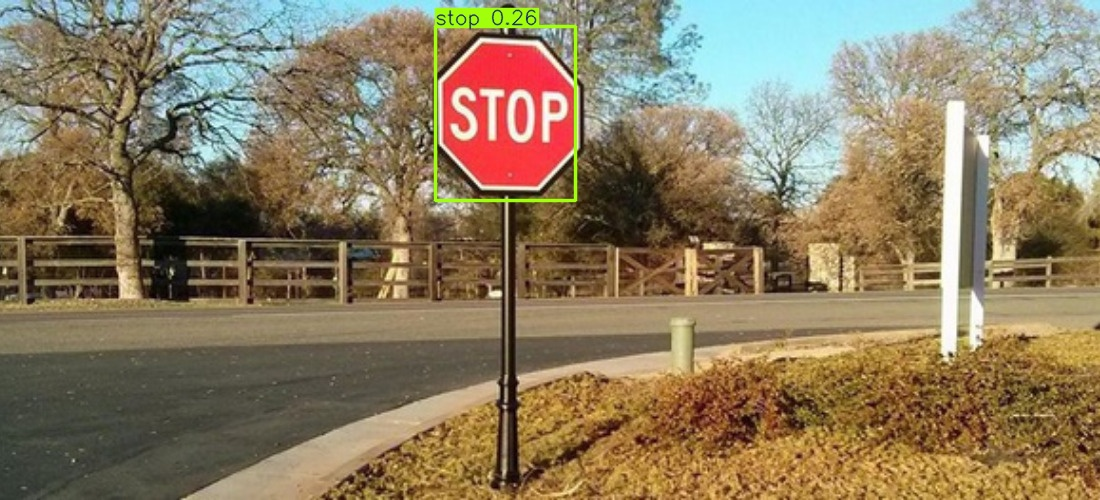

In [ ]:
# ====================================================
# 🧠 5. Test the trained YOLOv8 model on new images
# ====================================================
from google.colab import files
from IPython.display import Image, display
import os

# Upload one or more test images
print("📤 Please upload one or more traffic sign images to test:")
uploaded = files.upload()

# Run prediction for each uploaded image
for img_name in uploaded.keys():
    print(f"\n🔍 Processing image: {img_name}")

    # Run YOLOv8 prediction
    results = model.predict(source=img_name, conf=0.25, save=True, show=False)
    r = results[0]

    # Check detection results
    num_detections = len(r.boxes)
    if num_detections == 0:
        print(f"❌ No traffic signs detected in {img_name}")
    else:
        print(f"✅ {num_detections} traffic sign(s) detected in {img_name}:")
        for i, box in enumerate(r.boxes):
            cls = int(box.cls[0])      # class index
            conf = float(box.conf[0])  # confidence
            label = r.names[cls]       # class name
            print(f"   {i+1}. {label} (confidence: {conf:.2f})")

    # Construct the saved image path properly
    output_path = os.path.join(r.save_dir, img_name)
    if os.path.exists(output_path):
        display(Image(filename=output_path))
    else:
        print(f"⚠️ Could not find output image at {output_path}")


Saving image2stop.jpg to image2stop (1).jpg


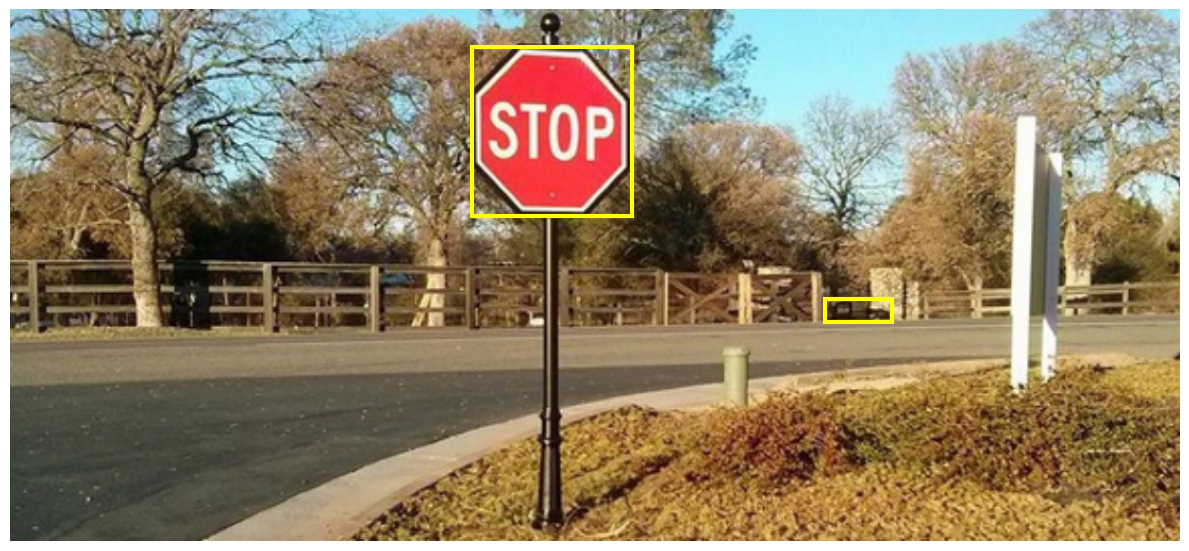

In [ ]:
# Colab-ready: upload image(s) and optional weights, run YOLOv8, display image(s) with bounding boxes only
!pip install -q ultralytics

from ultralytics import YOLO
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import io, os

# Upload image(s) and optionally upload a custom weights file (.pt) named best.pt
uploaded = files.upload()
filenames = list(uploaded.keys())
img_files = [f for f in filenames if f.lower().endswith(('.jpg','.jpeg','.png'))]
weights_file = next((f for f in filenames if f.lower().endswith('.pt')), None)
if len(img_files) == 0:
    raise SystemExit("No image uploaded.")

# Choose model path: custom weights if provided else yolov8x.pt
model_path = weights_file if weights_file else "yolov8x.pt"
model = YOLO(model_path)

# Inference and display (no labels, no saved annotated images)
for img_name in img_files:
    results = model.predict(source=img_name, conf=0.05, save=False, show=False, verbose=False)
    r = results[0] if len(results) > 0 else None

    img = Image.open(img_name).convert("RGB")
    fig, ax = plt.subplots(figsize=(12,8))
    ax.imshow(img)

    boxes = np.empty((0,4))
    if r is not None and hasattr(r, "boxes"):
        try:
            boxes = r.boxes.xyxy.cpu().numpy()
        except Exception:
            try:
                boxes = np.array([b.xyxy[0].cpu().numpy() for b in r.boxes])
            except Exception:
                boxes = np.empty((0,4))

    for b in boxes:
        x1, y1, x2, y2 = map(float, b[:4])
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=3, edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)

    ax.axis('off')
    plt.tight_layout()
    display(fig)
    plt.close(fig)

In [ ]:
model.export(format="onnx")  # export for deployment or further use


Ultralytics 8.3.218 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/traffic_sign_yolov8m_finetuned/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 46, 8400) (49.7 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 20.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 30.3s, saved as '/content/runs/detect/traffic_sign_yolov8m_finetuned/weights/best.onnx' (98.9 MB)

Export complete (32.1s)
Results saved to /content/runs/detect/traffic_sign_yolov8m_finetuned/weights
Predict:         yolo 

'/content/runs/detect/traffic_sign_yolov8m_finetuned/weights/best.onnx'